<a href="https://colab.research.google.com/github/Deepthi-1534/MACHINE-LEARNING-LAB/blob/main/K_MEANS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

# Upload your ZIP file
uploaded = files.upload()

Saving archive (5).zip to archive (5) (1).zip


In [7]:
import zipfile

# Extract ZIP to current directory
with zipfile.ZipFile('archive (5).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [8]:
import os

# List all files in current directory
os.listdir('.')

['.config',
 'archive (5) (1).zip',
 'archive (4).zip',
 'archive (5).zip',
 'Mall_Customers.csv',
 'sample_data']

In [9]:
import pandas as pd

# Replace filename if your CSV has a different name
df = pd.read_csv('Mall_Customers.csv')

# Check first 5 rows
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [11]:
# We use Annual Income and Spending Score
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

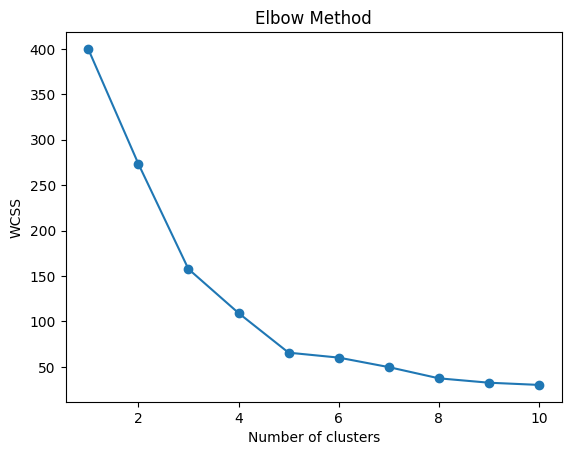

In [13]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

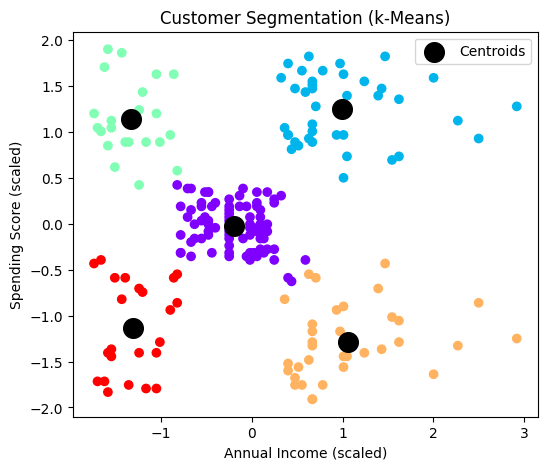

In [15]:
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Cluster'], cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('Customer Segmentation (k-Means)')
plt.legend()
plt.show()

In [20]:
df.to_csv('Mall_Customers_Clustered.csv', index=False)
print("Clustering completed. CSV file saved!")

Clustering completed. CSV file saved!
